In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import plotly.express as px
import plotly.graph_objects as go

In [3]:
data = pd.read_csv('books_data.csv')
data.head()

,bookID,title,authors,average_rating
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11127 entries, 0 to 11126
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   bookID          11127 non-null  int64 
 1   title           11127 non-null  object
 2   authors         11127 non-null  object
 3   average_rating  11127 non-null  object
dtypes: int64(1), object(3)
memory usage: 347.8+ KB


In [6]:
data.columns

Index(['bookID', 'title', 'authors', 'average_rating'], dtype='object')

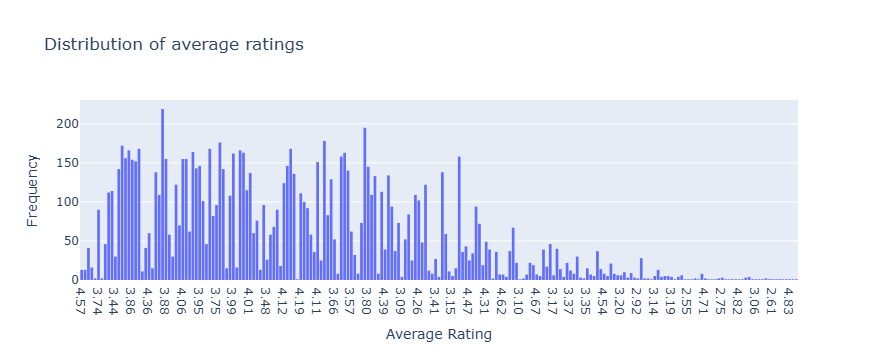

In [7]:
fig = px.histogram(data , x = 'average_rating' , nbins = 30 , title = "Distribution of average ratings")
fig.update_xaxes(title_text = 'Average Rating')
fig.update_yaxes(title_text = "Frequency")
fig.show()

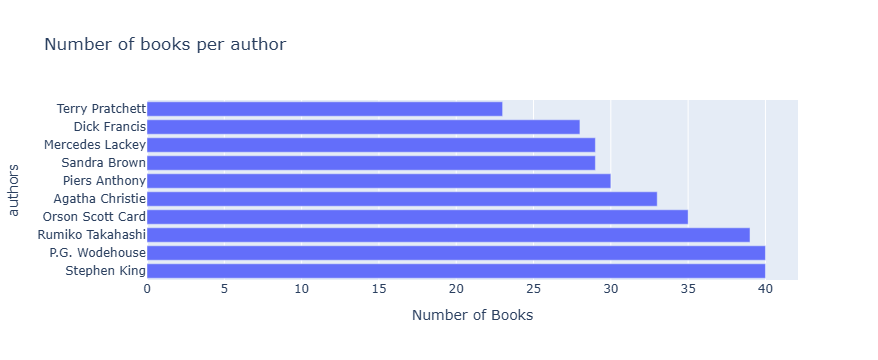

In [8]:
top_authors = data['authors'].value_counts().head(10)
fig = px.bar(top_authors , x = top_authors.values , y = top_authors.index , orientation = 'h' , labels = {'x':'Number of Books' , 'y' : 'Author'},title = 'Number of books per author')
fig.show()

In [9]:
#convert 'average_rating' to a numeric data type
data['average_rating'] = pd.to_numeric(data['average_rating'],errors='coerce')

In [12]:
#create a new column 'book_content'
data['book_content'] = data['title'] + ' ' + data['authors']

In [13]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(data['book_content'])

In [14]:
# compute cosine similarity
cosine_sim = linear_kernel(tfidf_matrix,tfidf_matrix)

In [19]:
def recommend_books(book_title, cosine_sim=cosine_sim):
    # Get the index of the book
    idx = data[data['title'] == book_title].index[0]

    # Get cosine similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort books based on similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get top 10 similar books (excluding the book itself)
    sim_scores = sim_scores[1:11]

    # Get book indices
    book_indices = [i[0] for i in sim_scores]

    # Return top 10 recommended books
    return data['title'].iloc[book_indices]


In [21]:
# Example
book_title = "Sam Walton: Made In America"
recommended_books = recommend_books(book_title)

print(recommended_books)

2788                              Dumpy's Valentine
3559         See You Around  Sam! (Sam Krupnik  #3)
7502                           The Song of Rhiannon
8998                   The Deming Management Method
3322                                   Buried Child
5850                                     Waterworks
454     Plays 1: Medea/The Phoenician Women/Bacchae
3323                                    Seven Plays
7575           Sam And The Firefly (Beginner Books)
6189          Dubliners: Text  Criticism  and Notes
Name: title, dtype: object
